# Notebook 3 — Exploratory Data Analysis
## Telecom Customer Retention Intelligence Platform

**Objective:** Explore relationships between customer attributes
and churn behavior. Identify the strongest churn drivers
before building predictive models.

**Input:** data/processed/telco_churn_cleaned.csv  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Chart styling
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Load Processed Data

In [2]:
df = pd.read_csv('../data/processed/telco_churn_cleaned.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nChurn distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].mean()*100:.1f}%")

Dataset shape: (7043, 31)

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%


## 2. Churn Rate by Contract Type
**Business question:** Which contract type has the highest churn risk?

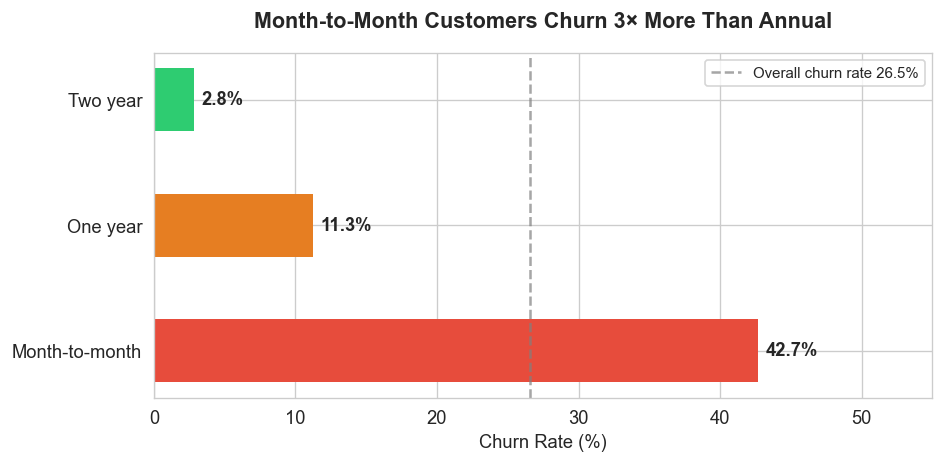


Key insight: Month-to-month churn rate is 42.7%


In [4]:
# Rebuild contract labels from encoded columns for visualization
df_viz = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')
df_viz['TotalCharges'] = pd.to_numeric(
    df_viz['TotalCharges'], errors='coerce'
)
df_viz['TotalCharges'].fillna(df_viz['TotalCharges'].median(), 
                               inplace=True)

# Churn rate by contract
contract_churn = df_viz.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
contract_churn.columns = ['Contract', 'ChurnRate']
contract_churn = contract_churn.sort_values('ChurnRate', 
                                             ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c', '#e67e22', '#2ecc71']
bars = ax.barh(contract_churn['Contract'], 
               contract_churn['ChurnRate'],
               color=colors, edgecolor='none', height=0.5)

for bar, val in zip(bars, contract_churn['ChurnRate']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold')

ax.set_title('Month-to-Month Customers Churn 3× More Than Annual',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Churn Rate (%)')
ax.set_xlim(0, 55)
ax.axvline(x=26.54, color='gray', linestyle='--', 
           alpha=0.7, label='Overall churn rate 26.5%')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../reports/churn_by_contract.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("\nKey insight: Month-to-month churn rate is",
      f"{contract_churn.iloc[0]['ChurnRate']:.1f}%")

## 3. Churn Rate by Tenure Group
**Business question:** At what stage of the customer 
lifecycle does churn peak?

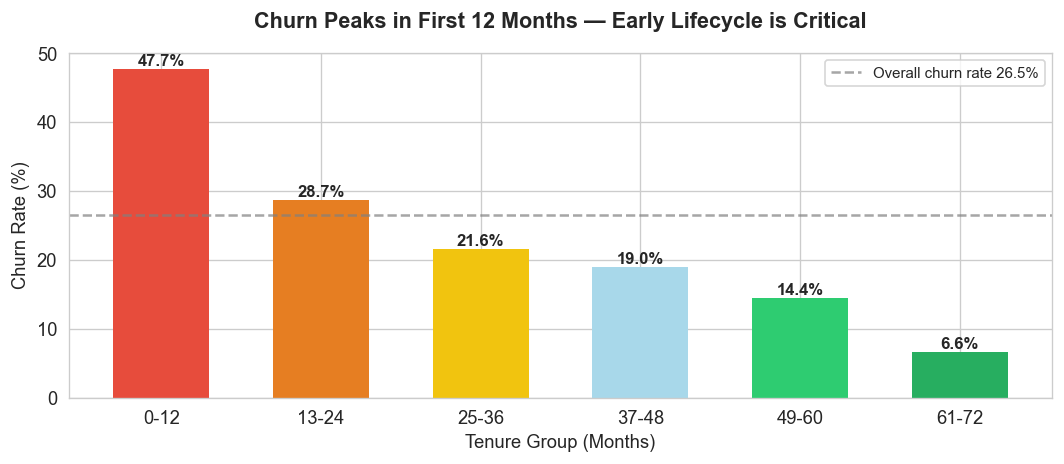

In [5]:
# Create tenure groups
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-12', '13-24', '25-36', '37-48', '49-60', '61-72']
df_viz['TenureGroup'] = pd.cut(df_viz['tenure'], 
                                bins=bins, labels=labels)

tenure_churn = df_viz.groupby('TenureGroup')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
tenure_churn.columns = ['TenureGroup', 'ChurnRate']

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#e74c3c', '#e67e22', '#f1c40f', 
          '#a8d8ea', '#2ecc71', '#27ae60']

bars = ax.bar(tenure_churn['TenureGroup'], 
              tenure_churn['ChurnRate'],
              color=colors, edgecolor='none', width=0.6)

for bar, val in zip(bars, tenure_churn['ChurnRate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Churn Peaks in First 12 Months — '
             'Early Lifecycle is Critical',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Tenure Group (Months)')
ax.set_ylabel('Churn Rate (%)')
ax.axhline(y=26.54, color='gray', linestyle='--',
           alpha=0.7, label='Overall churn rate 26.5%')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../reports/churn_by_tenure.png', 
            dpi=150, bbox_inches='tight')
plt.show()

## 4. Churn Rate by Internet Service
**Business question:** Does service type affect churn risk?

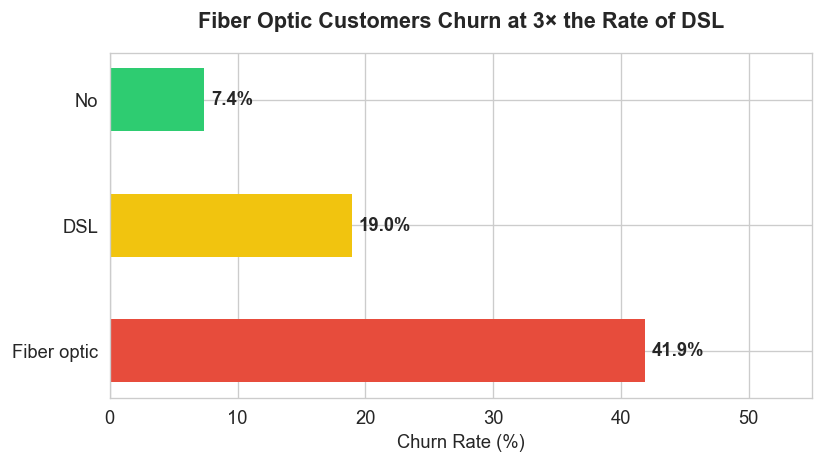

In [6]:
internet_churn = df_viz.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
internet_churn.columns = ['InternetService', 'ChurnRate']
internet_churn = internet_churn.sort_values('ChurnRate', 
                                             ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#e74c3c', '#f1c40f', '#2ecc71']
bars = ax.barh(internet_churn['InternetService'],
               internet_churn['ChurnRate'],
               color=colors, edgecolor='none', height=0.5)

for bar, val in zip(bars, internet_churn['ChurnRate']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold')

ax.set_title('Fiber Optic Customers Churn at '
             '3× the Rate of DSL',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Churn Rate (%)')
ax.set_xlim(0, 55)

plt.tight_layout()
plt.savefig('../reports/churn_by_internet.png', 
            dpi=150, bbox_inches='tight')
plt.show()

## 5. Monthly Charges Distribution — Churned vs Retained
**Business question:** Do higher paying customers churn more?

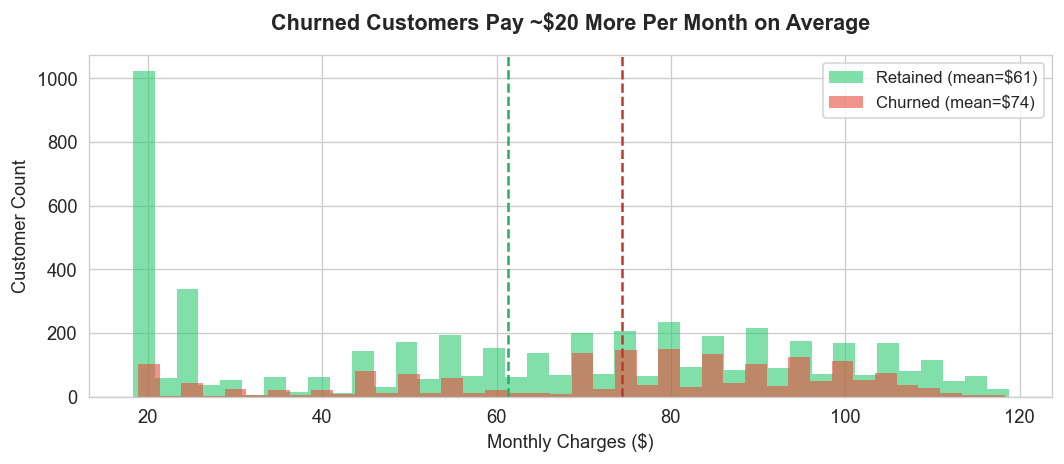

Average monthly charges — Retained: $61.27
Average monthly charges — Churned:  $74.44
Difference: $13.18


In [7]:
fig, ax = plt.subplots(figsize=(9, 4))

churned = df_viz[df_viz['Churn'] == 'Yes']['MonthlyCharges']
retained = df_viz[df_viz['Churn'] == 'No']['MonthlyCharges']

ax.hist(retained, bins=40, alpha=0.6, color='#2ecc71',
        label=f'Retained (mean=${retained.mean():.0f})',
        edgecolor='none')
ax.hist(churned, bins=40, alpha=0.6, color='#e74c3c',
        label=f'Churned (mean=${churned.mean():.0f})',
        edgecolor='none')

ax.axvline(retained.mean(), color='#27ae60', 
           linestyle='--', linewidth=1.5)
ax.axvline(churned.mean(), color='#c0392b', 
           linestyle='--', linewidth=1.5)

ax.set_title('Churned Customers Pay ~$20 More Per Month on Average',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Customer Count')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../reports/monthly_charges_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Average monthly charges — Retained: ${retained.mean():.2f}")
print(f"Average monthly charges — Churned:  ${churned.mean():.2f}")
print(f"Difference: ${churned.mean() - retained.mean():.2f}")

## 6. Correlation Heatmap
**Business question:** Which numerical features correlate 
most strongly with churn?

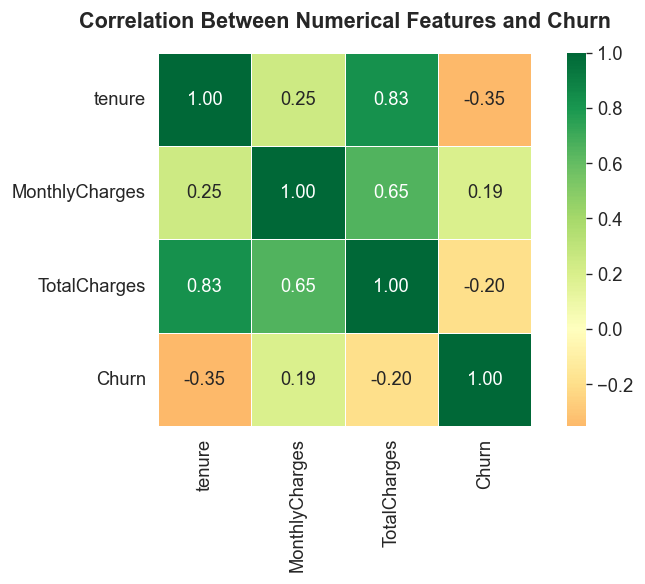


Correlation with Churn:
tenure           -0.352229
TotalCharges     -0.199037
MonthlyCharges    0.193356
Churn             1.000000
Name: Churn, dtype: float64


In [8]:
# Use the processed encoded dataframe for correlation
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            ax=ax)

ax.set_title('Correlation Between Numerical Features and Churn',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelation with Churn:")
print(corr_matrix['Churn'].sort_values())

## 7. Churn Rate by Payment Method
**Business question:** Does payment method signal churn risk?

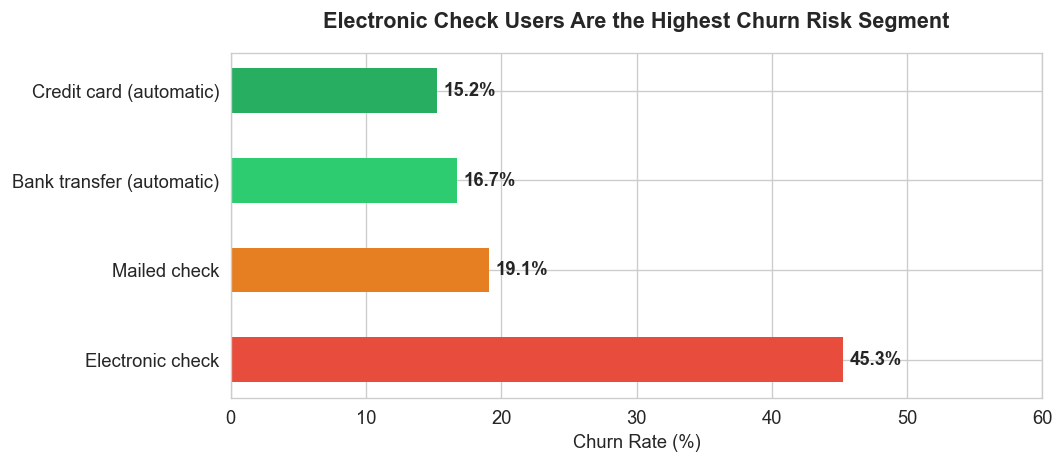

In [9]:
payment_churn = df_viz.groupby('PaymentMethod')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
payment_churn.columns = ['PaymentMethod', 'ChurnRate']
payment_churn = payment_churn.sort_values('ChurnRate',
                                           ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#27ae60']
bars = ax.barh(payment_churn['PaymentMethod'],
               payment_churn['ChurnRate'],
               color=colors, edgecolor='none', height=0.5)

for bar, val in zip(bars, payment_churn['ChurnRate']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold')

ax.set_title('Electronic Check Users Are the '
             'Highest Churn Risk Segment',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Churn Rate (%)')
ax.set_xlim(0, 60)

plt.tight_layout()
plt.savefig('../reports/churn_by_payment.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 8. EDA Summary — Key Business Insights

| # | Insight | Business Implication |
|---|---|---|
| 1 | Month-to-month customers churn at ~42% | Convert to annual contracts as priority retention offer |
| 2 | Churn peaks in first 12 months at ~47% | Invest heavily in early onboarding experience |
| 3 | Fiber optic customers churn at ~42% | Investigate service quality and pricing competitiveness |
| 4 | Churned customers pay ~$20 more per month | High-value customers are leaving — revenue impact is severe |
| 5 | Electronic check users churn at ~45% | Payment method is a behavioral disengagement signal |
| 6 | Tenure is negatively correlated with churn | Longer relationships mean stronger loyalty |

